In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import re
from pathlib import Path
from typing import List
from tbparse import SummaryReader

In [2]:
project_root = Path.cwd()
if not (project_root / "runs").exists():
    project_root = project_root.parent

In [ ]:
import matplotlib

FIGURES_DIR = project_root / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

matplotlib.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
    }
)

### BP experiments (from bp_only notebook)


In [4]:
BP_EXPERIMENT_NAMES = [
    "experiment_only_backprop_20260604_090527",
    "experiment_only_backprop_20260604_090543",
    "experiment_only_backprop_20260604_090556",
]
BP_EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in BP_EXPERIMENT_NAMES]

bp_experiments = []
for exp_dir in BP_EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs"):
            bp_experiments.append(str(subdir.relative_to(project_root)))

bp_results = [
    str((project_root / "results" / Path(e).name).relative_to(project_root)) + ".json" for e in bp_experiments
]
bp_experiments

['runs/experiment_only_backprop_20260604_090527/bp_cnn_fashionmnist_proj2048_20260604_091754_seed1231',
 'runs/experiment_only_backprop_20260604_090527/bp_cnn_mnist_proj2048_20260604_090700_seed1231',
 'runs/experiment_only_backprop_20260604_090527/bp_cnn_cifar10_proj2048_20260604_093058_seed1231',
 'runs/experiment_only_backprop_20260604_090527/bp_cnn_cifar100_proj2048_20260604_095348_seed1231',
 'runs/experiment_only_backprop_20260604_090543/bp_cnn_cifar100_proj2048_20260604_110305_seed3845',
 'runs/experiment_only_backprop_20260604_090543/bp_cnn_fashionmnist_proj2048_20260604_102801_seed3845',
 'runs/experiment_only_backprop_20260604_090543/bp_cnn_cifar10_proj2048_20260604_104028_seed3845',
 'runs/experiment_only_backprop_20260604_090543/bp_cnn_mnist_proj2048_20260604_101646_seed3845',
 'runs/experiment_only_backprop_20260604_090556/bp_cnn_mnist_proj2048_20260604_112607_seed92389',
 'runs/experiment_only_backprop_20260604_090556/bp_cnn_fashionmnist_proj2048_20260604_113652_seed92389

## MF+AD / MF+DD experiments (from acc_comparison notebook)


In [5]:
# MF+AD and MLP BP: from experiment_all dirs (bp_autodiff runs only)
AD_EXPERIMENT_NAMES = [
    "experiment_all_20260528_114458",
    "experiment_all_20260528_114510",
    "experiment_all_20260528_114532",
]
AD_EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in AD_EXPERIMENT_NAMES]

# MF+DD: from experiment_only_dd dirs
DD_EXPERIMENT_NAMES = [
    "experiment_only_dd_20260614_090030",
    "experiment_only_dd_20260614_090031",
]
DD_EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in DD_EXPERIMENT_NAMES]

MF_EXPERIMENT_DIRS = AD_EXPERIMENT_DIRS  # used by SummaryReader for MF+AD timing

mf_experiments = []
for exp_dir in AD_EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs") and subdir.name.startswith("bp_autodiff"):
            mf_experiments.append(str(subdir.relative_to(project_root)))

dd_experiments = []
for exp_dir in DD_EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs"):
            dd_experiments.append(str(subdir.relative_to(project_root)))

mf_results = [
    str((project_root / "results" / Path(e).name).relative_to(project_root)) + ".json" for e in mf_experiments
]
dd_results = [
    str((project_root / "results" / Path(e).name).relative_to(project_root)) + ".json" for e in dd_experiments
]
mf_experiments[:4]

['runs/experiment_all_20260528_114458/bp_autodiff_cnn_mnist_20260528_114616_seed155',
 'runs/experiment_all_20260528_114458/bp_autodiff_cnn_fashionmnist_20260528_120603_seed155',
 'runs/experiment_all_20260528_114458/bp_autodiff_cnn_cifar10_20260528_123132_seed155',
 'runs/experiment_all_20260528_114458/bp_autodiff_mlp_cifar10_20260528_143321_seed155']

## Training time

Derived from TensorBoard wall-clock timestamps: `max(wall_clock) - min(wall_clock)` per run directory.


In [6]:
bp_tb_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in BP_EXPERIMENT_DIRS
]
df_bp = pd.concat(bp_tb_dfs, ignore_index=True)
df_bp = df_bp.assign(
    wall_clock=pd.to_datetime(df_bp["wall_time"], unit="s", utc=True),
    architecture=df_bp["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    dataset=df_bp["dir_name"].str.extract(r"_(mnist|fashionmnist|cifar\d+)_")[0],
    seed=df_bp["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time"])

print(df_bp.shape)
df_bp.head(2)

(9600, 8)


,step,tag,value,dir_name,wall_clock,architecture,dataset,seed
0,1,backprop/bp/acc/train,0.152156,bp_cnn_cifar100_proj2048_20260604_095348_seed1231,2026-06-04 07:54:05.701327324+00:00,cnn,cifar100,1231
1,2,backprop/bp/acc/train,0.275089,bp_cnn_cifar100_proj2048_20260604_095348_seed1231,2026-06-04 07:54:12.121021986+00:00,cnn,cifar100,1231


In [7]:
mf_tb_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in MF_EXPERIMENT_DIRS
]
df_mf = pd.concat(mf_tb_dfs, ignore_index=True)
df_mf = df_mf.assign(
    wall_clock=pd.to_datetime(df_mf["wall_time"], unit="s", utc=True),
    architecture=df_mf["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    dataset=df_mf["dir_name"].str.extract(r"_(mnist|fashionmnist|cifar\d+)_")[0],
    seed=df_mf["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time"])

print(df_mf.shape)
df_mf.head(2)

(196800, 8)


,step,tag,value,dir_name,wall_clock,architecture,dataset,seed
0,1,autodiff/layer_acc/layer_0/train,0.012200,bp_autodiff_cnn_cifar100_20260528_131519_seed155,2026-05-28 11:15:37.269617319+00:00,cnn,cifar100,155
1,2,autodiff/layer_acc/layer_0/train,0.016289,bp_autodiff_cnn_cifar100_20260528_131519_seed155,2026-05-28 11:15:43.609385014+00:00,cnn,cifar100,155


In [8]:
dd_tb_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in DD_EXPERIMENT_DIRS
]
df_dd_tb = pd.concat(dd_tb_dfs, ignore_index=True)
df_dd_tb = df_dd_tb.assign(
    wall_clock=pd.to_datetime(df_dd_tb["wall_time"], unit="s", utc=True),
    architecture=df_dd_tb["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    dataset=df_dd_tb["dir_name"].str.extract(r"_(mnist|fashionmnist|cifar\d+)_")[0],
    seed=df_dd_tb["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time"])

print(df_dd_tb.shape)
df_dd_tb.head(2)

(88800, 8)


,step,tag,value,dir_name,wall_clock,architecture,dataset,seed
0,1,dd/layer_acc/layer_0/train,0.012733,dd_cnn_cifar100_P4_proj16_20260614_220944_seed42,2026-06-14 20:10:33.671242476+00:00,cnn,cifar100,42
1,2,dd/layer_acc/layer_0/train,0.017378,dd_cnn_cifar100_P4_proj16_20260614_220944_seed42,2026-06-14 20:11:12.324743986+00:00,cnn,cifar100,42


In [9]:
def compute_timing(df: pd.DataFrame, phase: str) -> pd.DataFrame:
    rows = []
    for dir_name, grp in df.groupby("dir_name"):
        duration_min = (grp["wall_clock"].max() - grp["wall_clock"].min()).total_seconds() / 60
        r = grp.iloc[0]
        rows.append(
            dict(
                method=phase,
                arch=r["architecture"],
                dataset=r["dataset"],
                seed=r["seed"],
                duration_min=duration_min,
            )
        )
    return pd.DataFrame(rows)


# CNN BP timing: from bp_only runs
bp_timing = compute_timing(df_bp, phase="bp")


# MF+AD and MLP BP timing: split by tag prefix from mf runs (experiment_all dirs)
def phase_of(tag: str) -> str:
    prefix = tag.split("/")[0]
    return {"backprop": "bp", "autodiff": "mf_ad", "dd": "mf_dd"}.get(prefix, None)


df_mf = df_mf.assign(phase=df_mf["tag"].map(phase_of))

mf_timing_rows = []
for (dir_name, phase), grp in df_mf.groupby(["dir_name", "phase"]):
    if phase is None or phase == "mf_dd":
        continue
    arch = grp.iloc[0]["architecture"]
    # CNN BP timing comes from bp_only; skip the backprop phase in mf runs for cnn
    if phase == "bp" and arch == "cnn":
        continue
    duration_min = (grp["wall_clock"].max() - grp["wall_clock"].min()).total_seconds() / 60
    r = grp.iloc[0]
    mf_timing_rows.append(
        dict(
            method=phase,
            arch=arch,
            dataset=r["dataset"],
            seed=r["seed"],
            duration_min=duration_min,
        )
    )

# MF+DD timing: from experiment_only_dd runs
for dir_name, grp in df_dd_tb.groupby("dir_name"):
    duration_min = (grp["wall_clock"].max() - grp["wall_clock"].min()).total_seconds() / 60
    r = grp.iloc[0]
    mf_timing_rows.append(
        dict(
            method="mf_dd",
            arch=r["architecture"],
            dataset=r["dataset"],
            seed=r["seed"],
            duration_min=duration_min,
        )
    )

mf_timing = pd.DataFrame(mf_timing_rows)

timing_raw = pd.concat([bp_timing, mf_timing], ignore_index=True)
timing_agg = timing_raw.groupby(["arch", "method", "dataset"])["duration_min"].agg(mean="mean", std="std").reset_index()
timing_raw.pivot_table(index=["arch", "method", "dataset"], columns="seed", values="duration_min").sort_index()

seed                         42          123        155        200      \
arch method dataset                                                      
cnn  bp     cifar10              NaN         NaN        NaN        NaN   
            cifar100             NaN         NaN        NaN        NaN   
            fashionmnist         NaN         NaN        NaN        NaN   
            mnist                NaN         NaN        NaN        NaN   
     mf_ad  cifar10              NaN         NaN  20.841860  21.006223   
            cifar100             NaN         NaN  21.065105  21.208130   
            fashionmnist         NaN         NaN  11.754428  11.587209   
            mnist                NaN         NaN   9.246970   9.210789   
     mf_dd  cifar10       122.506598  122.400939        NaN        NaN   
            cifar100      128.294809  128.622688        NaN        NaN   
            fashionmnist   39.531529   39.636442        NaN        NaN   
            mnist          21.839724   21.853035        NaN        NaN   
mlp  bp     cifar10              NaN         NaN   9.045943  10.134561   
            cifar100             NaN         NaN   9.276451   9.497632   
            fashionmnist         NaN         NaN   7.584727   7.167079   
            mnist                NaN         NaN   7.342680   7.060912   
     mf_ad  cifar10              NaN         NaN   9.205406  10.228624   
            cifar100             NaN         NaN   9.285126   9.686497   
            fashionmnist         NaN         NaN   7.789723   7.452677   
            mnist                NaN         NaN   7.637980   7.232563   
     mf_dd  cifar10        25.145548   24.616869        NaN        NaN   
            cifar100       26.224675   25.265185        NaN        NaN   
            fashionmnist    8.913161    8.972900        NaN        NaN   
            mnist           7.947150    8.060137        NaN        NaN   

seed                         456        1231       3845       92389    \
arch method dataset                                                     
cnn  bp     cifar10              NaN  20.976018  20.928824  21.024347   
            cifar100             NaN  21.297412  21.318247  21.613808   
            fashionmnist         NaN  11.432872  10.808327  10.908181   
            mnist                NaN   9.420063   8.940096   9.236387   
     mf_ad  cifar10              NaN        NaN        NaN        NaN   
            cifar100             NaN        NaN        NaN        NaN   
            fashionmnist         NaN        NaN        NaN        NaN   
            mnist                NaN        NaN        NaN        NaN   
     mf_dd  cifar10       123.046232        NaN        NaN        NaN   
            cifar100      129.715726        NaN        NaN        NaN   
            fashionmnist   39.872700        NaN        NaN        NaN   
            mnist          21.905566        NaN        NaN        NaN   
mlp  bp     cifar10              NaN        NaN        NaN        NaN   
            cifar100             NaN        NaN        NaN        NaN   
            fashionmnist         NaN        NaN        NaN        NaN   
            mnist                NaN        NaN        NaN        NaN   
     mf_ad  cifar10              NaN        NaN        NaN        NaN   
            cifar100             NaN        NaN        NaN        NaN   
            fashionmnist         NaN        NaN        NaN        NaN   
            mnist                NaN        NaN        NaN        NaN   
     mf_dd  cifar10        25.089949        NaN        NaN        NaN   
            cifar100       25.693541        NaN        NaN        NaN   
            fashionmnist    9.326117        NaN        NaN        NaN   
            mnist           8.400082        NaN        NaN        NaN   

seed                        1231123  
arch method dataset                  
cnn  bp     cifar10             NaN  
            cifar100            NaN  
            fashionmnist

## Accuracy


In [10]:
def parse_bp_result(res_path: str):
    stem = Path(res_path).stem
    arch = re.search(r"_(cnn|mlp)_", stem).group(1)
    dataset = re.search(r"_(mnist|fashionmnist|cifar10|cifar100)_", stem).group(1)
    seed = int(re.search(r"_seed(\d+)$", stem).group(1))
    return arch, dataset, seed


bp_rows = []

# CNN BP: from bp_only experiments
for res in bp_results:
    arch, dataset, seed = parse_bp_result(res)
    data = json.loads((project_root / res).read_text())
    bp_rows.append(dict(method="bp", arch=arch, dataset=dataset, seed=seed, sub="ff", test_acc=data["bp"]["test_acc"]))

# MLP BP: from acc_comparison bp_autodiff experiments (data["bp"]["bp"]["test_acc"])
for res in mf_results:
    stem = Path(res).stem
    if not stem.startswith("bp_autodiff"):
        continue
    arch = re.search(r"_(cnn|mlp)_", stem).group(1)
    if arch != "mlp":
        continue
    dataset = re.search(r"_(mnist|fashionmnist|cifar10|cifar100)_", stem).group(1)
    seed = int(re.search(r"_seed(\d+)$", stem).group(1))
    data = json.loads((project_root / res).read_text())
    bp_rows.append(
        dict(method="bp", arch="mlp", dataset=dataset, seed=seed, sub="ff", test_acc=data["bp"]["bp"]["test_acc"])
    )

bp_raw = pd.DataFrame(bp_rows)
bp_raw.pivot_table(index=["arch", "dataset"], columns="seed", values="test_acc").sort_index()

seed               155      200      1231     3845     92389    1231123
arch dataset                                                           
cnn  cifar10           NaN      NaN   0.7296   0.7294   0.7343      NaN
     cifar100          NaN      NaN   0.4286   0.4294   0.4323      NaN
     fashionmnist      NaN      NaN   0.9095   0.9107   0.9114      NaN
     mnist             NaN      NaN   0.9886   0.9887   0.9899      NaN
mlp  cifar10        0.4910   0.4855      NaN      NaN      NaN   0.4830
     cifar100       0.2065   0.2115      NaN      NaN      NaN   0.2046
     fashionmnist   0.8801   0.8745      NaN      NaN      NaN   0.8820
     mnist          0.9731   0.9716      NaN      NaN      NaN   0.9731

In [11]:
def parse_mf_result(res_path: str):
    stem = Path(res_path).stem
    arch = re.search(r"_(cnn|mlp)_", stem).group(1)
    dataset = re.search(r"_(mnist|fashionmnist|cifar10|cifar100)_", stem).group(1)
    seed = int(re.search(r"_seed(\d+)$", stem).group(1))
    return arch, dataset, seed


mf_rows = []

# MF+AD accuracy: from experiment_all bp_autodiff runs
for res in mf_results:
    arch, dataset, seed = parse_mf_result(res)
    data = json.loads((project_root / res).read_text())
    mf_rows.append(
        dict(
            method="mf_ad",
            arch=arch,
            dataset=dataset,
            seed=seed,
            sub="ff",
            test_acc=data["autodiff"]["mono_ff"]["test_acc"],
        )
    )
    mf_rows.append(
        dict(
            method="mf_ad",
            arch=arch,
            dataset=dataset,
            seed=seed,
            sub="bp",
            test_acc=data["autodiff"]["mono_bp"]["test_acc"],
        )
    )

# MF+DD accuracy: from experiment_only_dd runs
for res in dd_results:
    arch, dataset, seed = parse_mf_result(res)
    data = json.loads((project_root / res).read_text())
    mf_rows.append(
        dict(method="mf_dd", arch=arch, dataset=dataset, seed=seed, sub="ff", test_acc=data["mono_ff"]["test_acc"])
    )
    mf_rows.append(
        dict(method="mf_dd", arch=arch, dataset=dataset, seed=seed, sub="bp", test_acc=data["mono_bp"]["test_acc"])
    )

mf_raw = pd.DataFrame(mf_rows)
mf_raw.head(4)

,method,arch,dataset,seed,sub,test_acc
0,mf_ad,cnn,mnist,155,ff,0.9663
1,mf_ad,cnn,mnist,155,bp,0.9725
2,mf_ad,cnn,fashionmnist,155,ff,0.8860
3,mf_ad,cnn,fashionmnist,155,bp,0.8897


In [12]:
raw = pd.concat([bp_raw, mf_raw], ignore_index=True)
acc_agg = raw.groupby(["arch", "method", "sub", "dataset"])["test_acc"].agg(mean="mean", std="std").reset_index()
raw.pivot_table(index=["arch", "method", "sub", "dataset"], columns="seed", values="test_acc").sort_index()

seed                          42       123      155      200      456      \
arch method sub dataset                                                     
cnn  bp     ff  cifar10           NaN      NaN      NaN      NaN      NaN   
                cifar100          NaN      NaN      NaN      NaN      NaN   
                fashionmnist      NaN      NaN      NaN      NaN      NaN   
                mnist             NaN      NaN      NaN      NaN      NaN   
     mf_ad  bp  cifar10           NaN      NaN   0.5359   0.5466      NaN   
                cifar100          NaN      NaN   0.2678   0.2700      NaN   
                fashionmnist      NaN      NaN   0.8897   0.8905      NaN   
                mnist             NaN      NaN   0.9725   0.9710      NaN   
            ff  cifar10           NaN      NaN   0.5463   0.5590      NaN   
                cifar100          NaN      NaN   0.2735   0.2772      NaN   
                fashionmnist      NaN      NaN   0.8860   0.8834      NaN   
                mnist             NaN      NaN   0.9663   0.9652      NaN   
     mf_dd  bp  cifar10        0.3874   0.3818      NaN      NaN   0.3906   
                cifar100       0.1562   0.1487      NaN      NaN   0.1491   
                fashionmnist   0.8268   0.8241      NaN      NaN   0.8305   
                mnist          0.9594   0.9543      NaN      NaN   0.9544   
            ff  cifar10        0.4103   0.4165      NaN      NaN   0.4278   
                cifar100       0.1792   0.1706      NaN      NaN   0.1795   
                fashionmnist   0.8439   0.8367      NaN      NaN   0.8446   
                mnist          0.9502   0.9471      NaN      NaN   0.9503   
mlp  bp     ff  cifar10           NaN      NaN   0.4910   0.4855      NaN   
                cifar100          NaN      NaN   0.2065   0.2115      NaN   
                fashionmnist      NaN      NaN   0.8801   0.8745      NaN   
                mnist             NaN      NaN   0.9731   0.9716      NaN   
     mf_ad  bp  cifar10           NaN      NaN   0.5202   0.5219      NaN   
                cifar100          NaN      NaN   0.1481   0.1475      NaN   
                fashionmnist      NaN      NaN   0.8606   0.8536      NaN   
                mnist             NaN      NaN   0.9467   0.9474      NaN   
            ff  cifar10           NaN      NaN   0.5212   0.5271      NaN   
                cifar100          NaN      NaN   0.1887   0.1864      NaN   
                fashionmnist      NaN      NaN   0.8623   0.8567      NaN   
                mnist             NaN      NaN   0.9488   0.9514      NaN   
     mf_dd  bp  cifar10        0.2997   0.3013      NaN      NaN   0.3004   
                cifar100       0.0669   0.0700      NaN      NaN   0.0692   
                fashionmnist   0.8208   0.8203      NaN      NaN   0.8206   
                mnist          0.9326   0.9317      NaN      NaN   0.9323   
            ff  cifar10        0.3765   0.3772      NaN      NaN   0.3744   
                cifar100       0.1101   0.1046      NaN      NaN   0.1134   
                fashionmnist   0.8347   0.8389      NaN      NaN   0.8379   
                mnist          0.9323   0.9323      NaN      NaN   0.9359   

seed                          1231     3845     92389    1231123  
arch method sub dataset                                           
cnn  bp     ff  cifar10        0.7296   0.7294   0.7343      NaN  
                cifar100       0.4286   0.4294   0.4323      NaN  
                fashionmnist   0.9095   0.9107   0.9114      NaN  
                mnist          0.9886   0.9887   0.9899      NaN  
     mf_ad  bp  cifar10           NaN      NaN      NaN   0.5375  
                cifar100          NaN      NaN      NaN   0.2658  
                fashionmnist      NaN      NaN      NaN   0.8839  
                mnist             NaN      NaN      NaN   0.9702  
            ff  cifar10           NaN      NaN      NaN   0.5498  
                cifar100    

## Combined accuracy + training time tables


In [13]:
DATASETS = ["mnist", "fashionmnist", "cifar10", "cifar100"]


def fmt_acc(mean, std):
    return f"{mean:.2f}\u00b1{std:.2f}"


def fmt_time(mean, std):
    return f"{mean:.1f}\u00b1{std:.1f} min"


def get_acc(arch, method, sub, ds):
    s = acc_agg[
        (acc_agg["arch"] == arch) & (acc_agg["method"] == method) & (acc_agg["sub"] == sub) & (acc_agg["dataset"] == ds)
    ]
    return s["mean"].item(), s["std"].item()


def get_time(arch, method, ds):
    s = timing_agg[(timing_agg["arch"] == arch) & (timing_agg["method"] == method) & (timing_agg["dataset"] == ds)]
    if s.empty:
        return float("nan"), float("nan")
    return s["mean"].item(), s["std"].item()


def make_table(arch: str) -> pd.DataFrame:
    records = []
    for ds in DATASETS:
        records.append(
            {
                "dataset": ds,
                "BP acc": fmt_acc(*get_acc(arch, "bp", "ff", ds)),
                "BP time": fmt_time(*get_time(arch, "bp", ds)),
                "MF+AD (ff) acc": fmt_acc(*get_acc(arch, "mf_ad", "ff", ds)),
                "MF+AD (bp) acc": fmt_acc(*get_acc(arch, "mf_ad", "bp", ds)),
                "MF+AD time": fmt_time(*get_time(arch, "mf_ad", ds)),
                "MF+DD (ff) acc": fmt_acc(*get_acc(arch, "mf_dd", "ff", ds)),
                "MF+DD (bp) acc": fmt_acc(*get_acc(arch, "mf_dd", "bp", ds)),
                "MF+DD time": fmt_time(*get_time(arch, "mf_dd", ds)),
            }
        )
    return pd.DataFrame(records).set_index("dataset")


print("MLP")
display(make_table("mlp"))
print("\nCNN")
display(make_table("cnn"))

MLP


,BP acc,BP time,MF+AD (ff) acc,MF+AD (bp) acc,MF+AD time,MF+DD (ff) acc,MF+DD (bp) acc,MF+DD time
dataset,,,,,,,,
mnist,0.97±0.00,7.3±0.2 min,0.95±0.00,0.95±0.00,7.4±0.2 min,0.93±0.00,0.93±0.00,8.1±0.2 min
fashionmnist,0.88±0.00,7.3±0.2 min,0.86±0.00,0.86±0.00,7.6±0.2 min,0.84±0.00,0.82±0.00,9.1±0.2 min
cifar10,0.49±0.00,9.5±0.6 min,0.53±0.00,0.52±0.00,9.6±0.5 min,0.38±0.00,0.30±0.00,25.0±0.3 min
cifar100,0.21±0.00,9.3±0.1 min,0.19±0.00,0.15±0.00,9.5±0.2 min,0.11±0.00,0.07±0.00,25.7±0.5 min



CNN


,BP acc,BP time,MF+AD (ff) acc,MF+AD (bp) acc,MF+AD time,MF+DD (ff) acc,MF+DD (bp) acc,MF+DD time
dataset,,,,,,,,
mnist,0.99±0.00,9.2±0.2 min,0.97±0.00,0.97±0.00,9.2±0.0 min,0.95±0.00,0.96±0.00,21.9±0.0 min
fashionmnist,0.91±0.00,11.0±0.3 min,0.88±0.00,0.89±0.00,11.6±0.1 min,0.84±0.00,0.83±0.00,39.7±0.2 min
cifar10,0.73±0.00,21.0±0.0 min,0.55±0.01,0.54±0.01,20.9±0.1 min,0.42±0.01,0.39±0.00,122.7±0.3 min
cifar100,0.43±0.00,21.4±0.2 min,0.27±0.00,0.27±0.00,21.1±0.1 min,0.18±0.01,0.15±0.00,128.9±0.7 min


## Training time bar chart


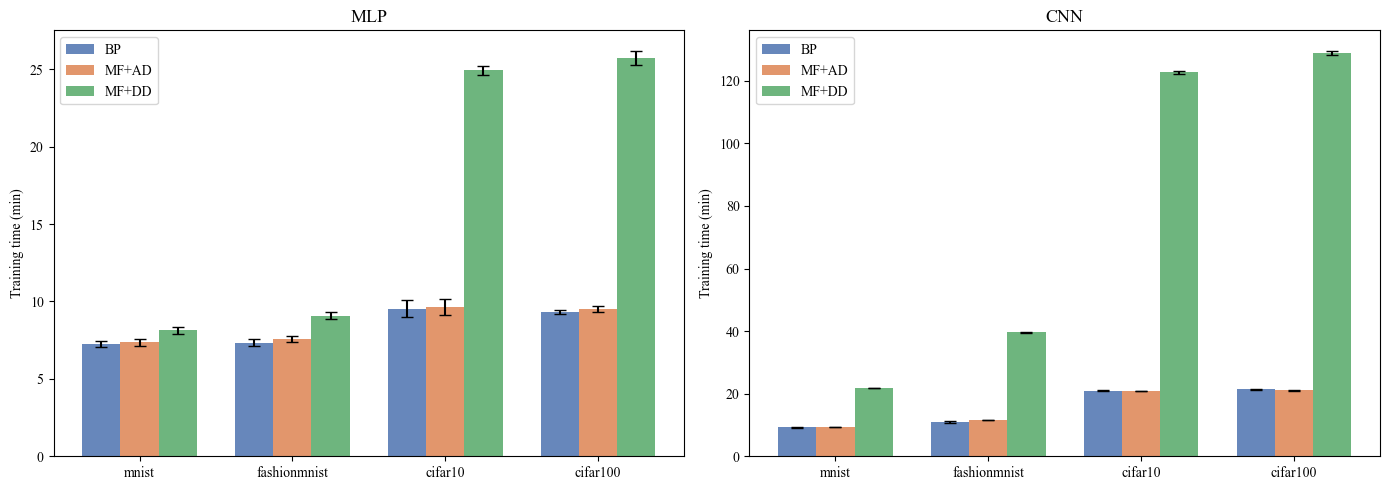

In [14]:
METHOD_ORDER = ["bp", "mf_ad", "mf_dd"]
METHOD_LABELS = {"bp": "BP", "mf_ad": "MF+AD", "mf_dd": "MF+DD"}
COLORS = {"bp": "#4C72B0", "mf_ad": "#DD8452", "mf_dd": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, arch in zip(axes, ["mlp", "cnn"]):
    x = np.arange(len(DATASETS))
    width = 0.25
    for i, method in enumerate(METHOD_ORDER):
        means, stds = [], []
        for ds in DATASETS:
            m, s = get_time(arch, method, ds)
            means.append(m)
            stds.append(s)
        ax.bar(
            x + i * width,
            means,
            width,
            yerr=stds,
            label=METHOD_LABELS[method],
            color=COLORS[method],
            capsize=4,
            alpha=0.85,
        )

    ax.set_title(arch.upper(), fontsize=13)
    ax.set_xticks(x + width)
    ax.set_xticklabels(DATASETS)
    ax.set_ylabel("Training time (min)")
    ax.legend()

# fig.suptitle("Training time per method and dataset (mean ± std across seeds)", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "training_time_comparison.pdf", bbox_inches="tight")
plt.show()

## Training time vs number of perturbations (MF+DD, FashionMNIST)


In [15]:
P_EXPERIMENT_NAMES = [
    "experiment_p_20260527_222827",
    "experiment_p_20260527_223212",
    "experiment_p_20260527_223216",
]
P_EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in P_EXPERIMENT_NAMES]

p_tb_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in P_EXPERIMENT_DIRS
]
df_p = pd.concat(p_tb_dfs, ignore_index=True)
df_p = df_p.assign(
    wall_clock=pd.to_datetime(df_p["wall_time"], unit="s", utc=True),
    architecture=df_p["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    num_perturbations=df_p["dir_name"].str.extract(r"_P(\d+)_")[0].astype(int),
    seed=df_p["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time"])

print(df_p.shape)
df_p.head(2)

(86400, 8)


,step,tag,value,dir_name,wall_clock,architecture,num_perturbations,seed
0,1,dd/layer_acc/layer_0/train,0.204648,dd_cnn_fashionmnist_P1_20260527_222957_seed42,2026-05-27 20:30:11.346196890+00:00,cnn,1,42
1,2,dd/layer_acc/layer_0/train,0.329407,dd_cnn_fashionmnist_P1_20260527_222957_seed42,2026-05-27 20:30:15.772918940+00:00,cnn,1,42


In [16]:
p_timing_rows = []
for (dir_name, arch, num_p, seed), grp in df_p.groupby(["dir_name", "architecture", "num_perturbations", "seed"]):
    duration_min = (grp["wall_clock"].max() - grp["wall_clock"].min()).total_seconds() / 60
    p_timing_rows.append(dict(arch=arch, num_perturbations=num_p, seed=seed, duration_min=duration_min))

p_timing_raw = pd.DataFrame(p_timing_rows)
p_timing_agg = (
    p_timing_raw.groupby(["arch", "num_perturbations"])["duration_min"].agg(mean="mean", std="std").reset_index()
)
p_timing_raw.pivot_table(index=["arch", "num_perturbations"], columns="seed", values="duration_min").sort_index()

seed                          42         100        123
arch num_perturbations                                 
cnn  1                  14.737104  14.886267  14.749230
     2                  23.778116  23.242994  23.421286
     4                  42.285982  40.389917  40.603950
     8                  75.099644  74.595214  74.758035
mlp  1                   7.790300   7.423626   7.583811
     2                   8.818047   8.293959   8.093908
     4                   9.386028   9.463384   9.351963
     8                  11.868719  11.679839  11.688870

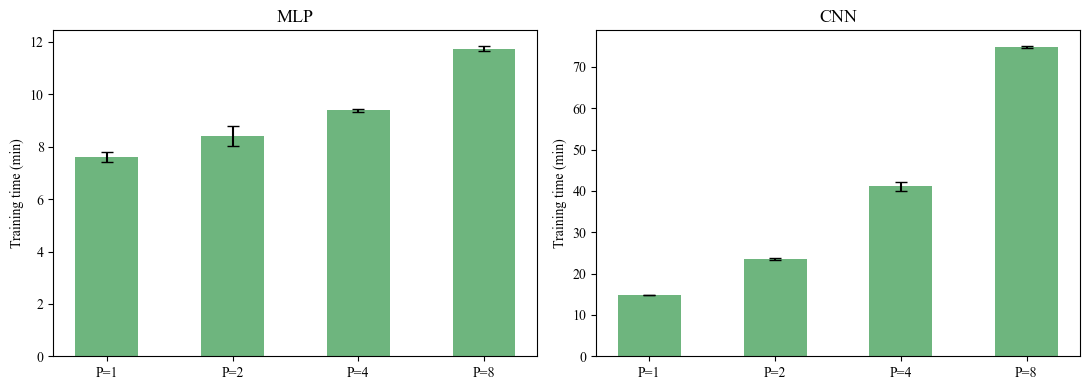

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, arch in zip(axes, ["mlp", "cnn"]):
    sub = p_timing_agg[p_timing_agg["arch"] == arch].sort_values("num_perturbations")
    P_vals = sub["num_perturbations"].tolist()
    ax.bar(
        range(len(P_vals)),
        sub["mean"],
        yerr=sub["std"],
        color=COLORS["mf_dd"],
        capsize=4,
        alpha=0.85,
        width=0.5,
    )
    ax.set_xticks(range(len(P_vals)))
    ax.set_xticklabels([f"P={p}" for p in P_vals])
    ax.set_title(arch.upper(), fontsize=13)
    ax.set_ylabel("Training time (min)")

# fig.suptitle("MF+DD training time vs P (FashionMNIST, mean ± std across seeds)", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "training_time_vs_P.pdf", bbox_inches="tight")
plt.show()